## Scenario

A patient comes with weight →
We calculate BMI →
Then classify health status

In [1]:
# # Define State
from typing import TypedDict

class HealthState(TypedDict):
    weight: float      # in kg
    height: float      # in meters
    bmi: float
    category: str

In [2]:
# Node 1 → Calculate BMI
def calculate_bmi(state: HealthState) -> HealthState:
    state["bmi"] = state["weight"] / (state["height"] ** 2)
    return state

In [3]:
# Node 2 → Classify BMI

def classify_bmi(state: HealthState) -> HealthState:
    bmi = state["bmi"]
    
    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"
        
    return state

In [4]:
# Build Graph
from langgraph.graph import StateGraph, START, END

builder = StateGraph(HealthState)

builder.add_node("bmi_node", calculate_bmi)
builder.add_node("classification_node", classify_bmi)

builder.add_edge(START, "bmi_node")
builder.add_edge("bmi_node", "classification_node")
builder.add_edge("classification_node", END)

graph = builder.compile()

c:\Users\User\Desktop\vccodepy\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


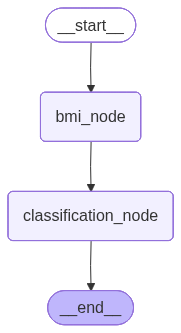

In [5]:
# Visualize Graph (Optional but Recommended)
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
# Run the Graph

result = graph.invoke({
    "weight": 70,   # kg
    "height": 1.75  # meters
})

print(result)

{'weight': 70, 'height': 1.75, 'bmi': 22.857142857142858, 'category': 'Normal'}
